# Progetto Robot learning 
“Idea of yours to further improve the sim-to-real transfer in our simple scenario”


## Environment
### Pusher
#### Reward
he total reward is: ***reward*** *=* *reward_dist + reward_ctrl + reward_near*.

    - *reward_dist*:
    This reward is a measure of how far the object is from the target goal position,
    with a more negative value assigned if the object is further away from the target.
    It is $-w_{dist} \|(P_{object} - P_{target})\|_2$.
    where $w_{dist}$ is the `reward_dist_weight` (default is $1$).
    - *reward_ctrl*:
    A negative reward to penalize the pusher for taking actions that are too large.
    It is measured as the negative squared Euclidean norm of the action, i.e. as $-w_{control} \|action\|_2^2$.
    where $w_{control}$ is the `reward_control_weight` (default is $0.1$).
    - *reward_near*:
    This reward is a measure of how far the *fingertip* of the pusher (the unattached end) is from the object,
    with a more negative value assigned for when the pusher's *fingertip* is further away from the target.
    It is $-w_{near} \|(P_{fingertip} - P_{target})\|_2$.
    where $w_{near}$ is the `reward_near_weight` (default is $0.5$).

 

### hopper

 
## RL API
La differenza principale tra PPO (Proximal Policy Optimization) e SAC (Soft Actor-Critic) risiede nella loro natura on-policy/off-policy e nei meccanismi utilizzati per stabilizzare l'apprendimento:
Natura dell'algoritmo: PPO è un metodo on-policy, il che significa che richiede nuovi campioni di dati per ogni aggiornamento del gradiente, rendendolo meno efficiente nel campionamento. SAC è invece off-policy, permettendo il riutilizzo di esperienze passate tramite un replay buffer, il che lo rende molto più efficiente in termini di campioni necessari.
Obiettivo e Stabilità:
PPO ottimizza una funzione obiettivo "surrogata" e utilizza una tecnica di clipping dei rapporti di probabilità per evitare aggiornamenti troppo grandi e distruttivi della politica.
SAC si basa sul framework della massima entropia: l'agente cerca di massimizzare non solo la ricompensa attesa, ma anche l'entropia della politica (ovvero agire nel modo più casuale possibile pur avendo successo). Questo favorisce l'esplorazione e previene la convergenza prematura.
Prestazioni: SAC ha dimostrato di essere più stabile e performante in compiti di controllo continuo ad alta dimensione rispetto ad altri metodi off-policy, superando spesso anche PPO in termini di velocità di apprendimento e punteggio finale.
Quindi il sac dovrebbe essere migliore nel ambiente dell’hopper dove le masse del corpo variano casualmente, nel caso di un analisi a lungo termine perchè esplora di più così da ottenere massime reward anche in situazioni peggiori. Mentre il PPO impara più velocemente perchè segue una policy precisa senza andare ad esplorare ma basandosi solo sugli ambienti dove ha avuto risultai migliori








## Road Map
- Hopper environment
- Variazione delle masse delle masse
- Determinare quale massa è più rilevante
- Come influisce lo scostarsi dal valore di target 
- Confronto tra PPO e SAC
- test sim-to-real


## TEST HOPPER
Per il test sull'hopper siamo partiti creando 9 ideali ambienti di test variando del 5%, 25% e 55% dai valori nominali di 
- massa delle parti
- attrito tra il pamivento e i piede
- massa e attrito contemporaneamente

Abbiamo ottenuto i seguenti risultati:

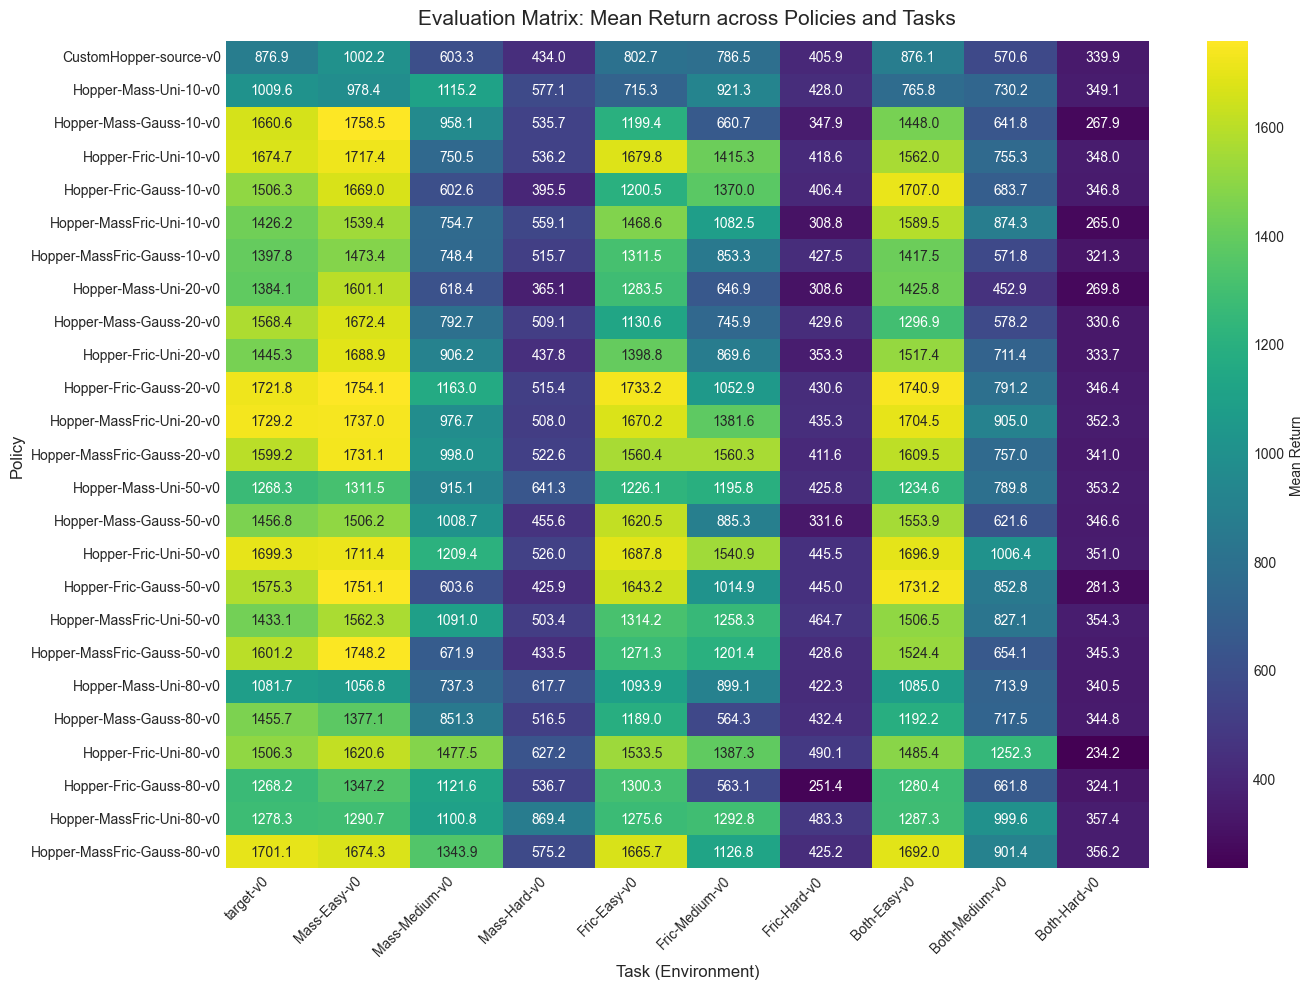

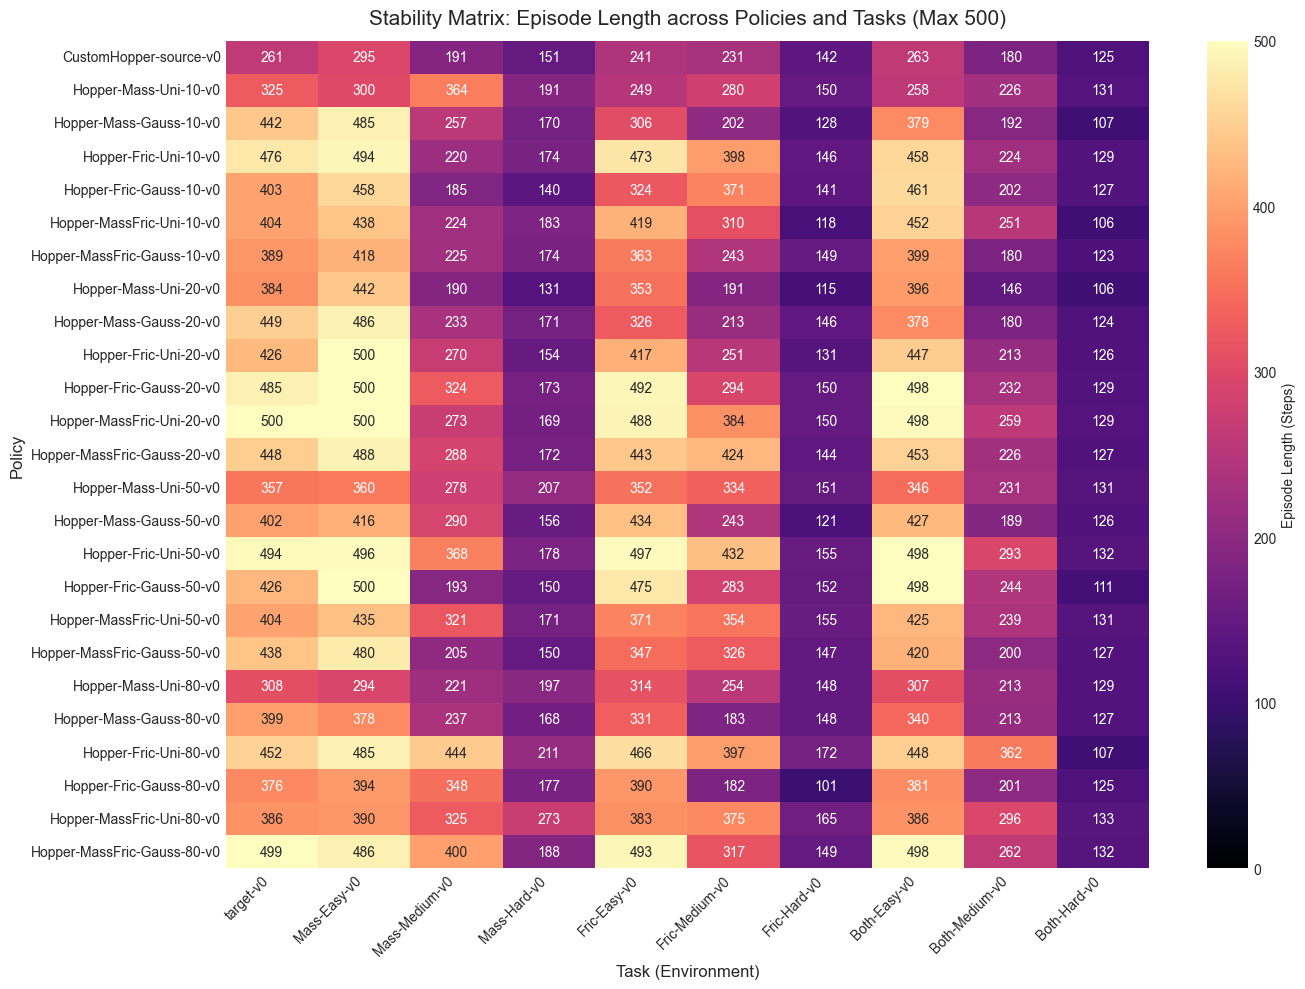

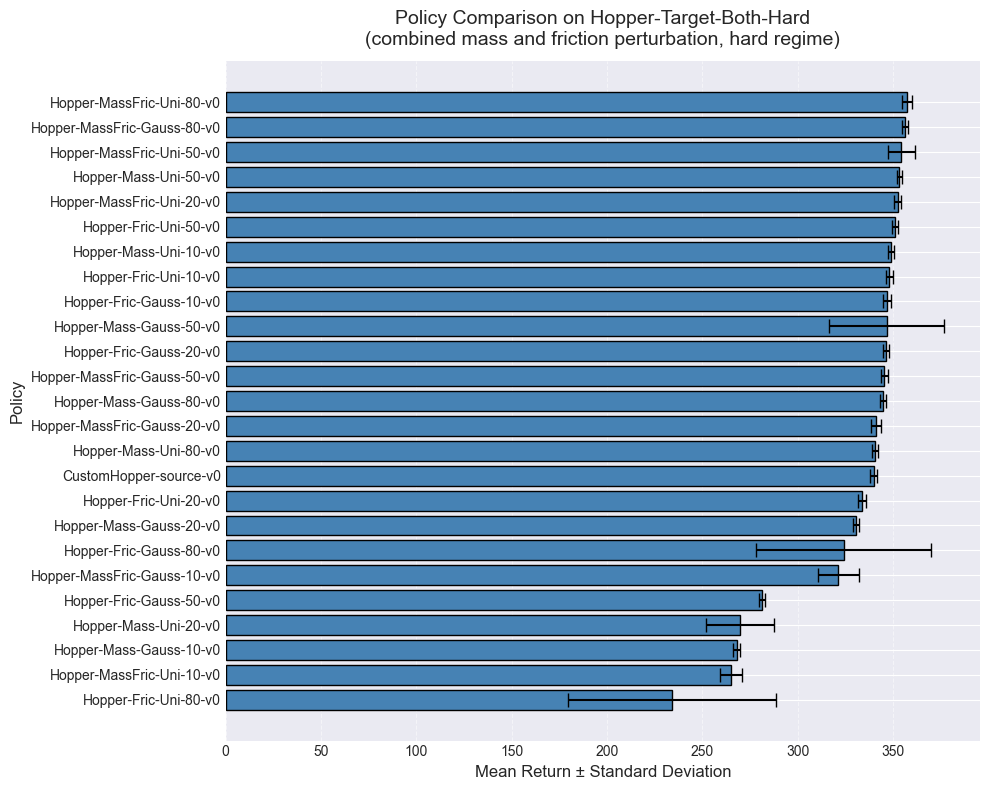

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Data loading ──────────────────────────────────────────────────────────────
df = pd.read_csv('HOPPER_ENV/PPO/results_v2/evaluation_matrix_v2.csv')

mean_cols = [c for c in df.columns if c.endswith('_mean')]
std_cols  = [c for c in df.columns if c.endswith('_std')]
len_cols  = [c for c in df.columns if c.endswith('_ep_len')]

clean_labels = [
    c.replace('_mean', '')
     .replace('Hopper-Target-', '')
     .replace('CustomHopper-', '')
    for c in mean_cols
]

# ── Visualisation 1: Mean Reward Heatmap ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

heatmap_data         = df[mean_cols].copy()
heatmap_data.index   = df['policy']
heatmap_data.columns = clean_labels

sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='viridis',
            cbar_kws={'label': 'Mean Return'}, ax=ax)

ax.set_title('Evaluation Matrix: Mean Return across Policies and Tasks', fontsize=15, pad=12)
ax.set_xlabel('Task (Environment)', fontsize=12)
ax.set_ylabel('Policy', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.setp(ax.get_xticklabels(), ha='right')

plt.tight_layout()
plt.savefig('heatmap_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Visualisation 2: Stability Heatmap (Episode Length) ──────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

heatmap_len         = df[len_cols].copy()
heatmap_len.index   = df['policy']
heatmap_len.columns = clean_labels

sns.heatmap(heatmap_len, annot=True, fmt=".0f", cmap='magma',
            vmin=0, vmax=500, cbar_kws={'label': 'Episode Length (Steps)'}, ax=ax)

ax.set_title('Stability Matrix: Episode Length across Policies and Tasks (Max 500)',
             fontsize=15, pad=12)
ax.set_xlabel('Task (Environment)', fontsize=12)
ax.set_ylabel('Policy', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.setp(ax.get_xticklabels(), ha='right')

plt.tight_layout()
plt.savefig('heatmap_stability.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Visualisation 3: Performance Comparison — Both-Hard ──────────────────────
target_mean = 'Hopper-Target-Both-Hard-v0_mean'
target_std  = 'Hopper-Target-Both-Hard-v0_std'

df_sorted = (df.dropna(subset=[target_mean, target_std])
               .sort_values(by=target_mean, ascending=True))

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(df_sorted['policy'], df_sorted[target_mean],
        xerr=df_sorted[target_std],
        color='steelblue', edgecolor='black', capsize=5)

ax.set_title('Policy Comparison on Hopper-Target-Both-Hard\n'
             '(combined mass and friction perturbation, hard regime)',
             fontsize=14, pad=12)
ax.set_xlabel('Mean Return ± Standard Deviation', fontsize=12)
ax.set_ylabel('Policy', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Analisi Ottimizzazione
Tramite l'algoritmo di Optuna abbiamo provato a massimizzare la reward media in un milione di timesteps per il modello con la maggior randomizzazione.

Migliori Parametri:
  learning_rate: 9.682609487894454e-05
  n_steps: 1024
  batch_size: 64
  n_epochs: 15
  gamma: 0.9948646413801842
  gae_lambda: 0.956474414048344
  clip_range: 0.17298348295317015
  ent_coef: 0.0002674701807186936
  vf_coef: 0.7848396206682986
  max_grad_norm: 0.7245950693318323


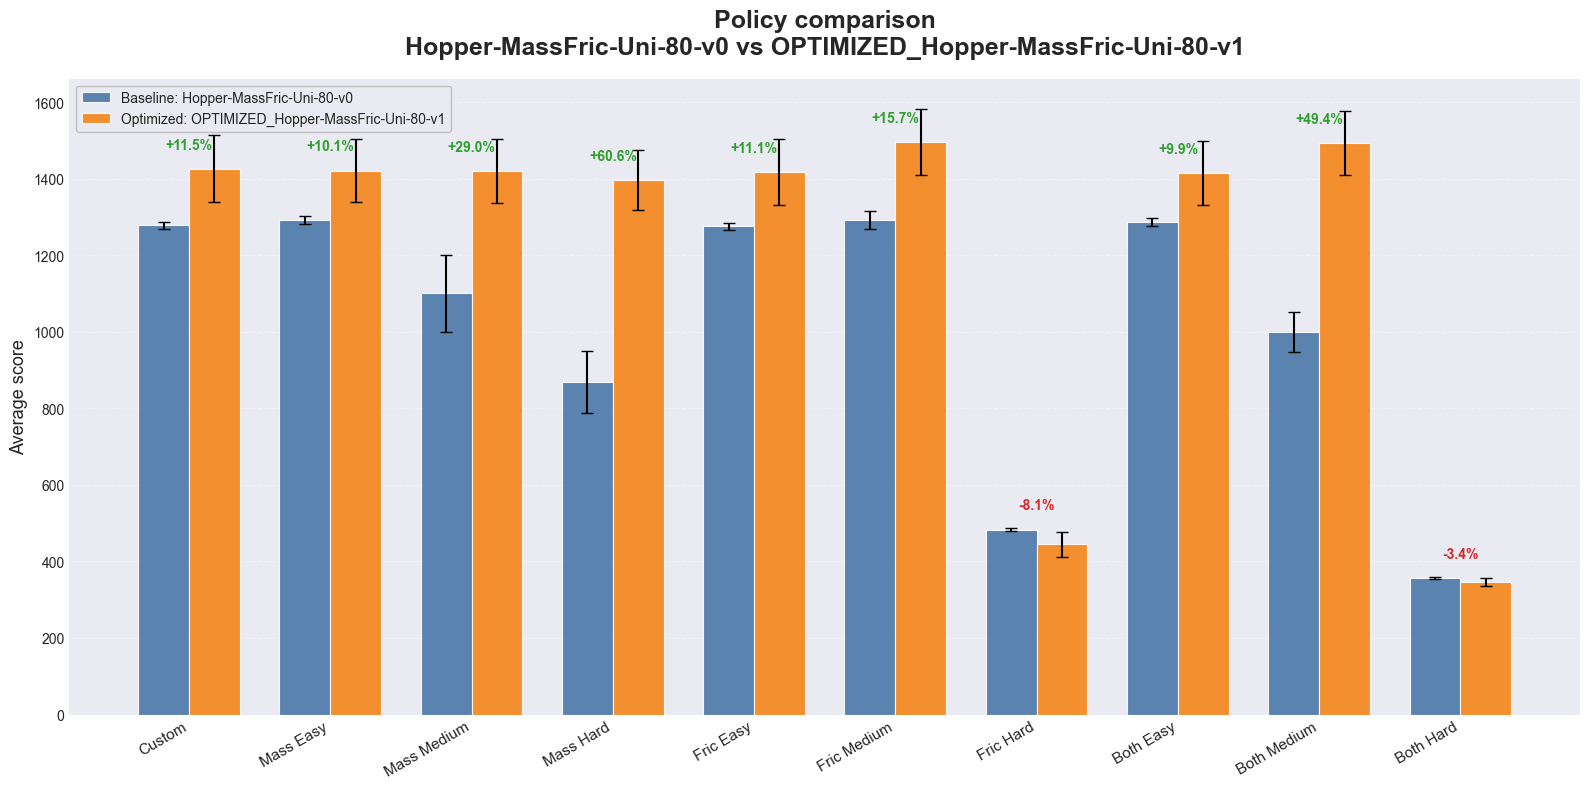

,metric,baseline,optimized,delta_pct
0,Custom,1278.29 ± 9.66,1425.9 ± 87.04,11.55
1,Mass Easy,1290.74 ± 10.43,1421.04 ± 81.59,10.09
2,Mass Medium,1100.8 ± 100.24,1419.81 ± 83.56,28.98
3,Mass Hard,869.4 ± 81.56,1396.31 ± 77.81,60.61
4,Fric Easy,1275.6 ± 9.61,1417.4 ± 87.09,11.12
5,Fric Medium,1292.83 ± 23.76,1496.03 ± 86.25,15.72
6,Fric Hard,483.34 ± 4.04,444.21 ± 31.77,-8.10
7,Both Easy,1287.29 ± 10.02,1414.67 ± 83.54,9.90
8,Both Medium,999.6 ± 52.7,1493.44 ± 84.18,49.40
9,Both Hard,357.38 ± 2.75,345.32 ± 10.48,-3.37


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# CONFIG
# =========================
base_file = "HOPPER_ENV/PPO/results_v2/evaluation_matrix_v2.csv"
opt_file = "HOPPER_ENV/PPO/results_v2/evaluation_matrix_OPTIMIZED.csv"

baseline_policy = "Hopper-MassFric-Uni-80-v0"  # <-- La policy di default corrispondente

# =========================
# LOAD DATA
# =========================
df_base = pd.read_csv(base_file)
df_opt = pd.read_csv(opt_file)

if baseline_policy not in df_base["policy"].values:
    raise ValueError(
        f"Policy '{baseline_policy}' non trovata!\n"
        f"Disponibili: {list(df_base['policy'])}"
    )

base_row = df_base[df_base["policy"] == baseline_policy].iloc[0]
opt_row = df_opt.iloc[0]
opt_policy_name = opt_row["policy"]

mean_cols = [c for c in df_base.columns if c.endswith("_mean")]

# =========================
# LABELS PIÙ LEGGIBILI
# =========================
label_map = {
    "CustomHopper-target-v0_mean": "Custom",
    "Hopper-Target-Mass-Easy-v0_mean": "Mass Easy",
    "Hopper-Target-Mass-Medium-v0_mean": "Mass Medium",
    "Hopper-Target-Mass-Hard-v0_mean": "Mass Hard",
    "Hopper-Target-Fric-Easy-v0_mean": "Fric Easy",
    "Hopper-Target-Fric-Medium-v0_mean": "Fric Medium",
    "Hopper-Target-Fric-Hard-v0_mean": "Fric Hard",
    "Hopper-Target-Both-Easy-v0_mean": "Both Easy",
    "Hopper-Target-Both-Medium-v0_mean": "Both Medium",
    "Hopper-Target-Both-Hard-v0_mean": "Both Hard",
}

results = []

for mean_col in mean_cols:
    std_col = mean_col.replace("_mean", "_std")
    
    baseline_mean = float(base_row[mean_col])
    baseline_std = float(base_row[std_col])
    optimized_mean = float(opt_row[mean_col])
    optimized_std = float(opt_row[std_col])
    
    delta_pct = 100 * (optimized_mean - baseline_mean) / baseline_mean if baseline_mean != 0 else np.nan

    results.append({
        "metric": label_map.get(mean_col, mean_col.replace("_mean", "")),
        "baseline_mean": baseline_mean,
        "baseline_std": baseline_std,
        "optimized_mean": optimized_mean,
        "optimized_std": optimized_std,
        "delta_pct": delta_pct
    })

df_plot = pd.DataFrame(results)

# =========================
# STILE PLOT
# =========================
plt.style.use("seaborn-v0_8-darkgrid")

baseline_color = "#4C78A8"
optimized_color = "#F58518"
text_color = "#EAEAF2"

x = np.arange(len(df_plot))
width = 0.36

fig, ax = plt.subplots(figsize=(16, 8))

bars1 = ax.bar(
    x - width/2,
    df_plot["baseline_mean"],
    width,
    yerr=df_plot["baseline_std"],
    capsize=4,
    label=f"Baseline: {baseline_policy}",
    color=baseline_color,
    alpha=0.90,
    edgecolor="white",
    linewidth=0.8
)

bars2 = ax.bar(
    x + width/2,
    df_plot["optimized_mean"],
    width,
    yerr=df_plot["optimized_std"],
    capsize=4,
    label=f"Optimized: {opt_policy_name}",
    color=optimized_color,
    alpha=0.90,
    edgecolor="white",
    linewidth=0.8
)

# Titolo e assi
ax.set_title(
    f"Policy comparison\n{baseline_policy} vs {opt_policy_name}",
    fontsize=18,
    fontweight="bold",
    pad=18
)
ax.set_ylabel("Average score", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(df_plot["metric"], rotation=30, ha="right", fontsize=11)

# Griglia più pulita
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)

# Legenda
leg = ax.legend(frameon=True, fancybox=True, framealpha=0.9)
leg.get_frame().set_edgecolor("#BBBBBB")

# Annotazioni delta %
for i, delta in enumerate(df_plot["delta_pct"]):
    ymax = max(df_plot.loc[i, "baseline_mean"], df_plot.loc[i, "optimized_mean"])
    ytext = ymax + max(df_plot["optimized_mean"].max(), df_plot["baseline_mean"].max()) * 0.03
    
    color = "#2ca02c" if delta >= 0 else "#d62728"
    ax.text(
        i,
        ytext,
        f"{delta:+.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=color
    )

# Rimuove spine superflue
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# =========================
# TABELLA RISULTATI PER JUPYTER
# =========================
df_table = df_plot.copy()
df_table["baseline"] = df_table["baseline_mean"].round(2).astype(str) + " ± " + df_table["baseline_std"].round(2).astype(str)
df_table["optimized"] = df_table["optimized_mean"].round(2).astype(str) + " ± " + df_table["optimized_std"].round(2).astype(str)
df_table["delta_pct"] = df_table["delta_pct"].round(2)

df_table = df_table[["metric", "baseline", "optimized", "delta_pct"]]
df_table


### SAC
Confronto della miglior policy ottenuta con il PPO utilizzando invece il SAC

Generazione Tabella Dati...



,PPO DR Reward,PPO DR Steps,PPO DR Var %,SAC Source Reward,SAC Source Steps,SAC Source Var %,SAC DR Reward,SAC DR Steps,SAC DR Var %
Target Environment,,,,,,,,,
Nominal Target,1278.29,386,+0.00%,1439.35,410,+0.00%,1180.89,351,+0.00%
Mass-Easy,1290.74,390,+0.97%,1687.84,479,+17.26%,1147.25,340,-2.85%
Mass-Medium,1100.80,325,-13.88%,651.33,211,-54.75%,974.76,300,-17.46%
Mass-Hard,869.40,273,-31.99%,349.59,136,-75.71%,648.71,211,-45.07%
Fric-Easy,1275.60,383,-0.21%,1466.80,421,+1.91%,1335.46,395,+13.09%
Fric-Medium,1292.83,375,+1.14%,956.28,267,-33.56%,1090.49,318,-7.66%
Fric-Hard,483.34,165,-62.19%,418.26,144,-70.94%,440.88,155,-62.67%
Both-Easy,1287.29,386,+0.70%,1553.05,442,+7.90%,1306.70,391,+10.65%
Both-Medium,999.60,296,-21.80%,698.55,213,-51.47%,666.47,214,-43.56%



Generazione Grafici...


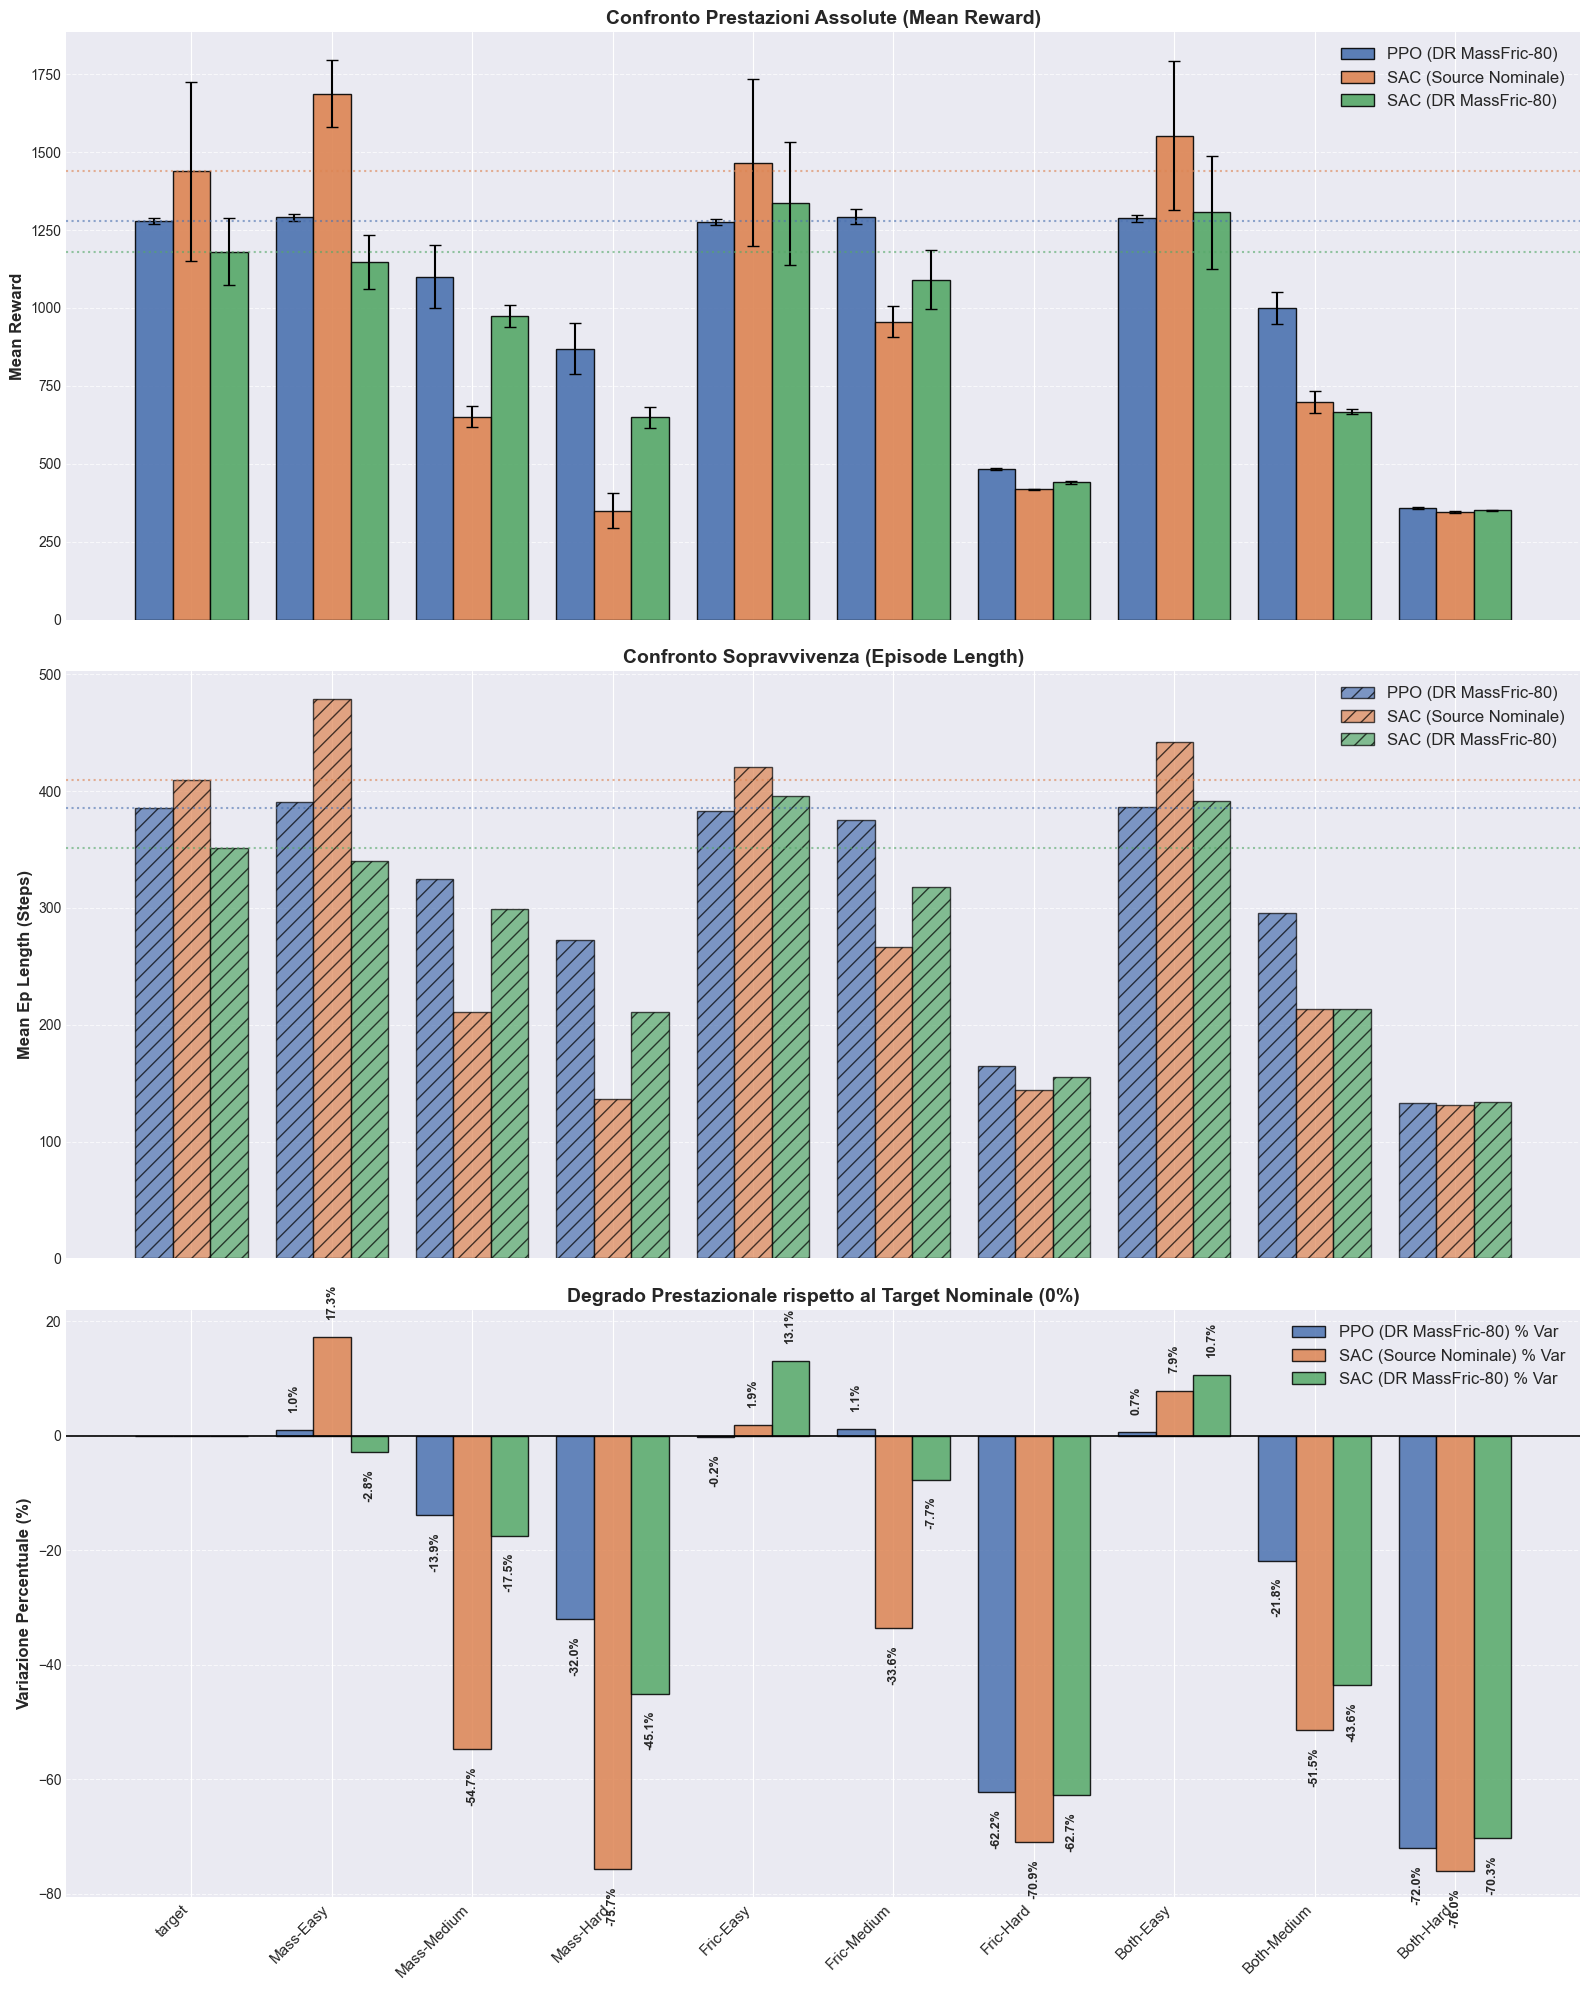

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Definizione dei percorsi
BASE_DIR = r"C:\Users\leona\Documents\Politecnico\Robot Learning\Esercitazione\Progetto\Renforcement_Learning_Project\HOPPER_ENV"
ppo_csv_path = os.path.join(BASE_DIR, "PPO", "results_v2", "evaluation_matrix_v2.csv")
sac_csv_path = os.path.join(BASE_DIR, "SAC", "results", "evaluation_matrix_SAC.csv")

# 2. Caricamento dei dati
df_ppo = pd.read_csv(ppo_csv_path) if os.path.exists(ppo_csv_path) else pd.DataFrame()
df_sac = pd.read_csv(sac_csv_path) if os.path.exists(sac_csv_path) else pd.DataFrame()

# 3. Estrazione intelligente dei 3 Modelli
# Cerca in modo parziale così è robusto contro versionamenti tipo -v0 o -v1
ppo_dr_df     = df_ppo[df_ppo['policy'].str.contains('MassFric-Uni-80', case=False, na=False)] if not df_ppo.empty else pd.DataFrame()
sac_source_df = df_sac[df_sac['policy'].str.contains('source', case=False, na=False)] if not df_sac.empty else pd.DataFrame()
sac_dr_df     = df_sac[df_sac['policy'].str.contains('MassFric-Uni-80', case=False, na=False)] if not df_sac.empty else pd.DataFrame()

has_ppo_dr     = not ppo_dr_df.empty
has_sac_source = not sac_source_df.empty
has_sac_dr     = not sac_dr_df.empty

if not (has_ppo_dr or has_sac_source or has_sac_dr):
    raise ValueError("ERRORE: Nessun modello trovato nei file CSV. Assicurati di aver generato evaluation_matrix.csv per entrambi!")

ppo_dr     = ppo_dr_df.iloc[0] if has_ppo_dr else None
sac_source = sac_source_df.iloc[0] if has_sac_source else None
sac_dr     = sac_dr_df.iloc[0] if has_sac_dr else None

target_ids = [
    "CustomHopper-target-v0", "Hopper-Target-Mass-Easy-v0", "Hopper-Target-Mass-Medium-v0",
    "Hopper-Target-Mass-Hard-v0", "Hopper-Target-Fric-Easy-v0", "Hopper-Target-Fric-Medium-v0",
    "Hopper-Target-Fric-Hard-v0", "Hopper-Target-Both-Easy-v0", "Hopper-Target-Both-Medium-v0",
    "Hopper-Target-Both-Hard-v0",
]
labels = [t.replace("Hopper-Target-", "").replace("CustomHopper-", "").replace("-v0", "") for t in target_ids]

# Funzione per calcolare le liste di mean, std, len e variazione %
def extract_stats(row):
    if row is None: return [], [], [], []
    means = [row[f"{t}_mean"] for t in target_ids]
    stds  = [row[f"{t}_std"] for t in target_ids]
    lens  = [row[f"{t}_ep_len"] for t in target_ids]
    base  = means[0]
    pct_vars = [((val - base) / base) * 100 if base != 0 else 0 for val in means]
    return means, stds, lens, pct_vars

ppo_means, ppo_stds, ppo_lens, ppo_vars = extract_stats(ppo_dr)
sac_src_means, sac_src_stds, sac_src_lens, sac_src_vars = extract_stats(sac_source)
sac_dr_means, sac_dr_stds, sac_dr_lens, sac_dr_vars = extract_stats(sac_dr)

# Prepara dinamicamente le info per il plotting
models_info = []
if has_ppo_dr:     models_info.append({"label": "PPO (DR MassFric-80)", "col_prefix": "PPO DR", "means": ppo_means, "stds": ppo_stds, "lens": ppo_lens, "vars": ppo_vars, "color": "#4C72B0"})
if has_sac_source: models_info.append({"label": "SAC (Source Nominale)", "col_prefix": "SAC Source", "means": sac_src_means, "stds": sac_src_stds, "lens": sac_src_lens, "vars": sac_src_vars, "color": "#DD8452"})
if has_sac_dr:     models_info.append({"label": "SAC (DR MassFric-80)", "col_prefix": "SAC DR", "means": sac_dr_means, "stds": sac_dr_stds, "lens": sac_dr_lens, "vars": sac_dr_vars, "color": "#55A868"})

# =====================================================================
# SEZIONE 1: CREAZIONE E VISUALIZZAZIONE TABELLA
# =====================================================================
data = []
for i, label in enumerate(labels):
    row_data = {"Target Environment": "Nominal Target" if label == "target" else label}
    for model in models_info:
        row_data[f"{model['col_prefix']} Reward"] = model['means'][i]
        row_data[f"{model['col_prefix']} Steps"] = model['lens'][i]
        row_data[f"{model['col_prefix']} Var %"] = model['vars'][i]
    data.append(row_data)

df_compare = pd.DataFrame(data)
df_compare.set_index("Target Environment", inplace=True)

# Raggruppa le colonne per tipo di algoritmo
cols = []
for model in models_info:
    cols.extend([f"{model['col_prefix']} Reward", f"{model['col_prefix']} Steps", f"{model['col_prefix']} Var %"])
df_compare = df_compare[cols]

def color_variation(val):
    if pd.isna(val): return ''
    color = '#d65f5f' if val < 0 else '#5fba7d'
    return f'color: {color}; font-weight: bold;'

format_dict = {f"{m['col_prefix']} Reward": "{:.2f}" for m in models_info}
format_dict.update({f"{m['col_prefix']} Steps": "{:.0f}" for m in models_info})
format_dict.update({f"{m['col_prefix']} Var %": "{:+.2f}%" for m in models_info})

styled_df = df_compare.style.format(format_dict, na_rep="-")
styled_df = styled_df.highlight_max(subset=[f"{m['col_prefix']} Reward" for m in models_info], color='lightgreen', axis=1)
styled_df = styled_df.map(color_variation, subset=[f"{m['col_prefix']} Var %" for m in models_info])
styled_df = styled_df.set_caption("Confronto: PPO (DR) vs SAC (Source) vs SAC (DR)") \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('text-align', 'center'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#f4f4f4'), ('color', 'black'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])

print("Generazione Tabella Dati...\n")
display(styled_df)


# =====================================================================
# SEZIONE 2: CREAZIONE E VISUALIZZAZIONE GRAFICI
# =====================================================================
print("\nGenerazione Grafici...")
x = np.arange(len(labels))
num_bars = len(models_info)
width = 0.8 / num_bars if num_bars > 0 else 0.5
offsets = np.linspace(-width*(num_bars-1)/2, width*(num_bars-1)/2, num_bars) if num_bars > 1 else [0]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 20), sharex=True)

for idx, model in enumerate(models_info):
    offset = offsets[idx]
    
    # --- SUBPLOT 1: MEAN REWARD ---
    ax1.bar(x + offset, model['means'], width, yerr=model['stds'], label=model['label'], capsize=4, color=model['color'], edgecolor='black', alpha=0.9)
    ax1.axhline(y=model['means'][0], color=model['color'], linestyle=':', alpha=0.6)
    
    # --- SUBPLOT 2: EPISODE LENGTH ---
    ax2.bar(x + offset, model['lens'], width, label=model['label'], color=model['color'], edgecolor='black', alpha=0.7, hatch='//')
    ax2.axhline(y=model['lens'][0], color=model['color'], linestyle=':', alpha=0.6)
    
    # --- SUBPLOT 3: VARIAZIONE PERCENTUALE (%) ---
    ax3.bar(x + offset, model['vars'], width, label=f"{model['label']} % Var", color=model['color'], edgecolor='black', alpha=0.85)
    
    # Testo % (scritto in verticale se ci sono troppe barre per non farle sovrapporre)
    for i in range(len(labels)):
        val = model['vars'][i]
        y_pos = val + (3 if val >= 0 else -3)
        va = 'bottom' if val >= 0 else 'top'
        if i != 0:
            ax3.text(x[i] + offset, y_pos, f"{val:.1f}%", ha='center', va=va, fontsize=9, fontweight='bold', rotation=90 if num_bars == 3 else 0)

ax1.set_ylabel('Mean Reward', fontsize=12, fontweight='bold')
ax1.set_title('Confronto Prestazioni Assolute (Mean Reward)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=12, loc='best')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2.set_ylabel('Mean Ep Length (Steps)', fontsize=12, fontweight='bold')
ax2.set_title('Confronto Sopravvivenza (Episode Length)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=12, loc='best')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

ax3.axhline(y=0, color='black', linewidth=1.2)
ax3.set_ylabel('Variazione Percentuale (%)', fontsize=12, fontweight='bold')
ax3.set_title('Degrado Prestazionale rispetto al Target Nominale (0%)', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
ax3.legend(fontsize=12, loc='best')
ax3.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplots_adjust(bottom=0.15) 
plt.tight_layout()
plt.show()


## Test Pusher


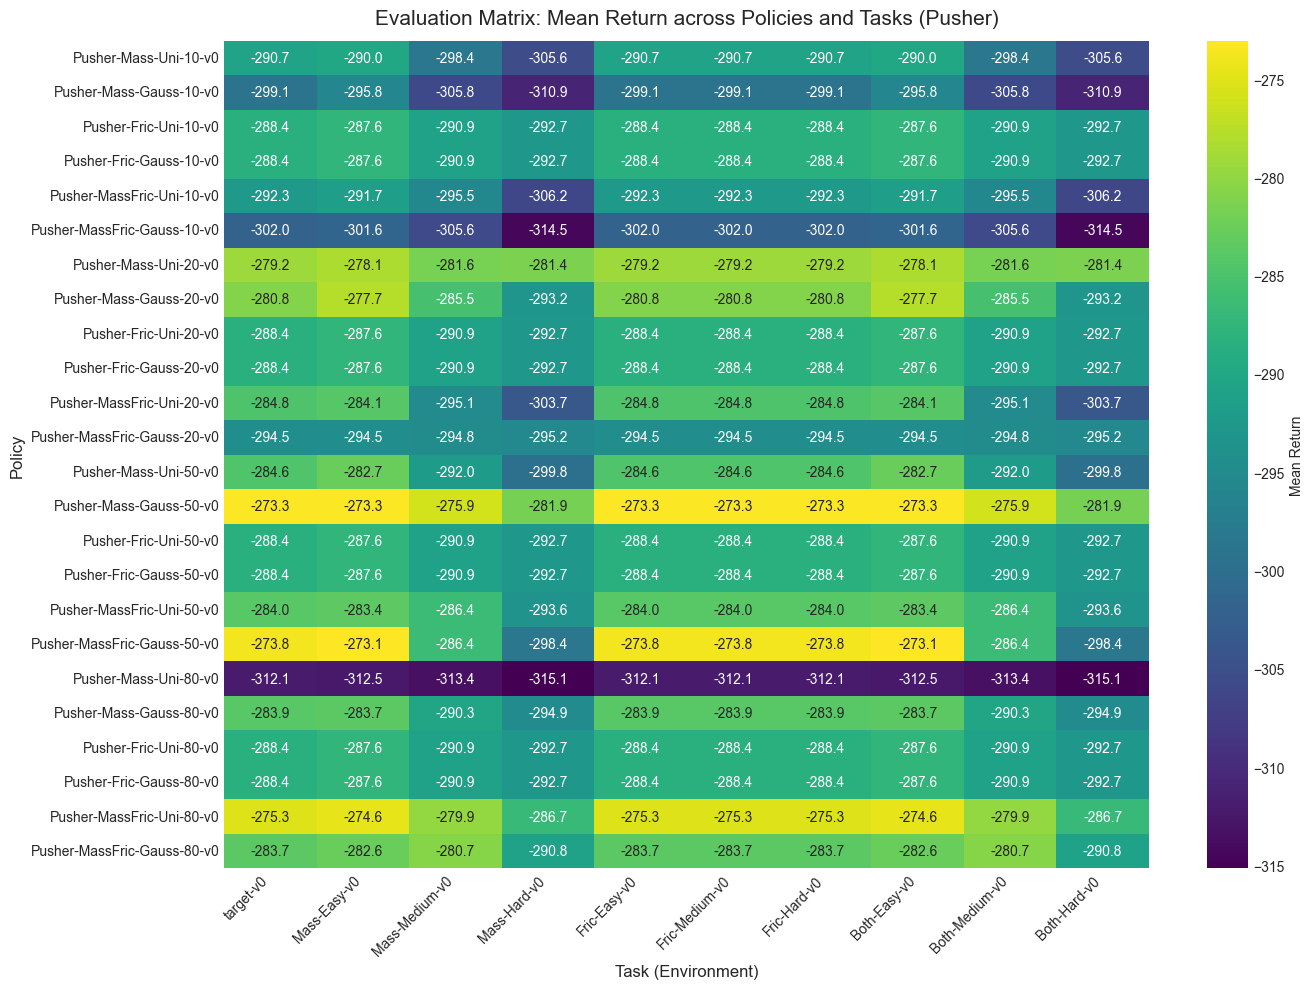

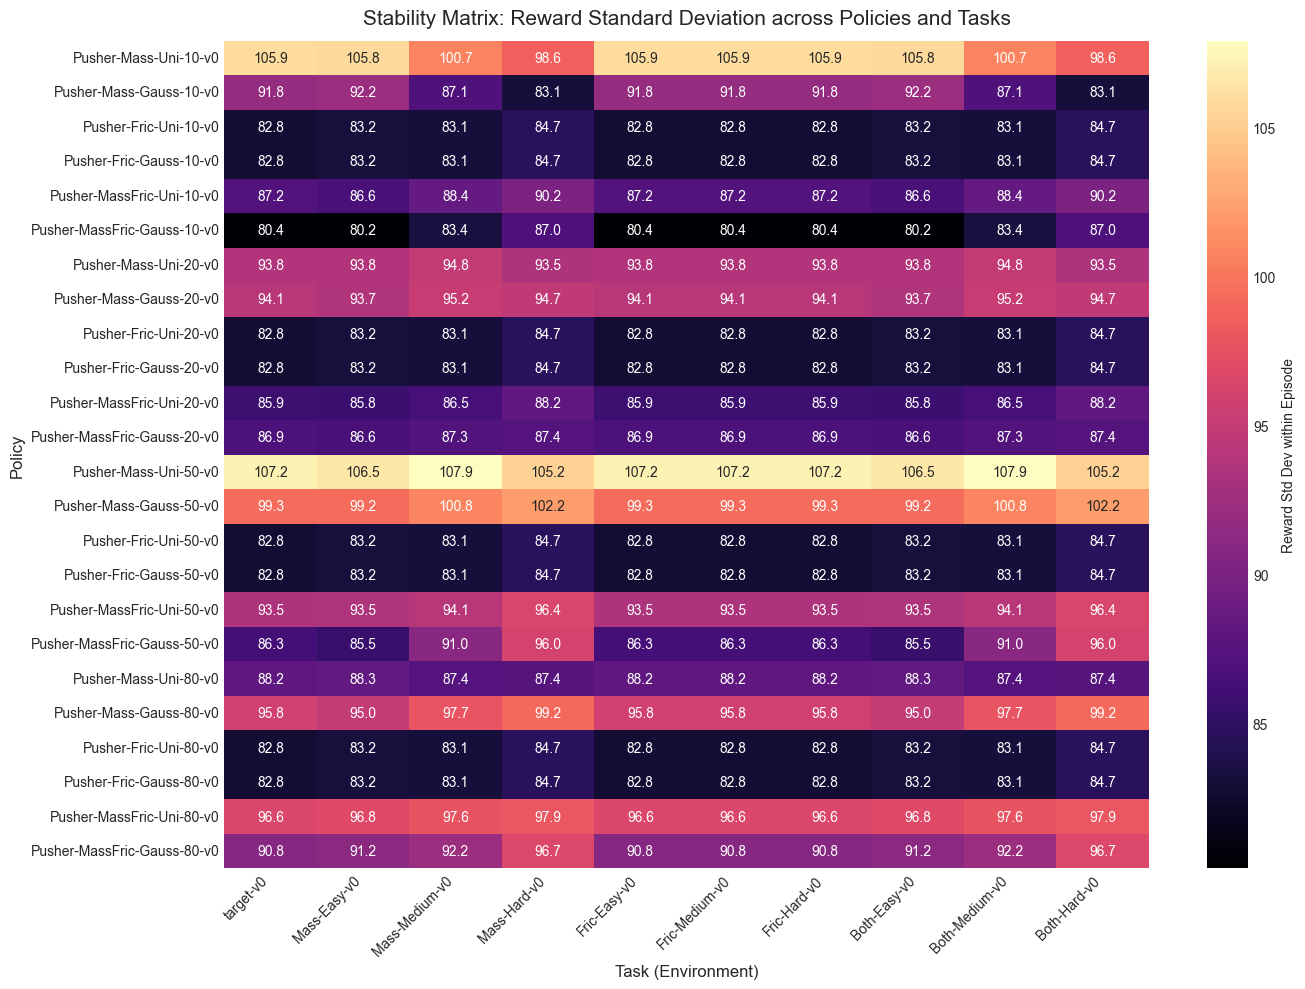

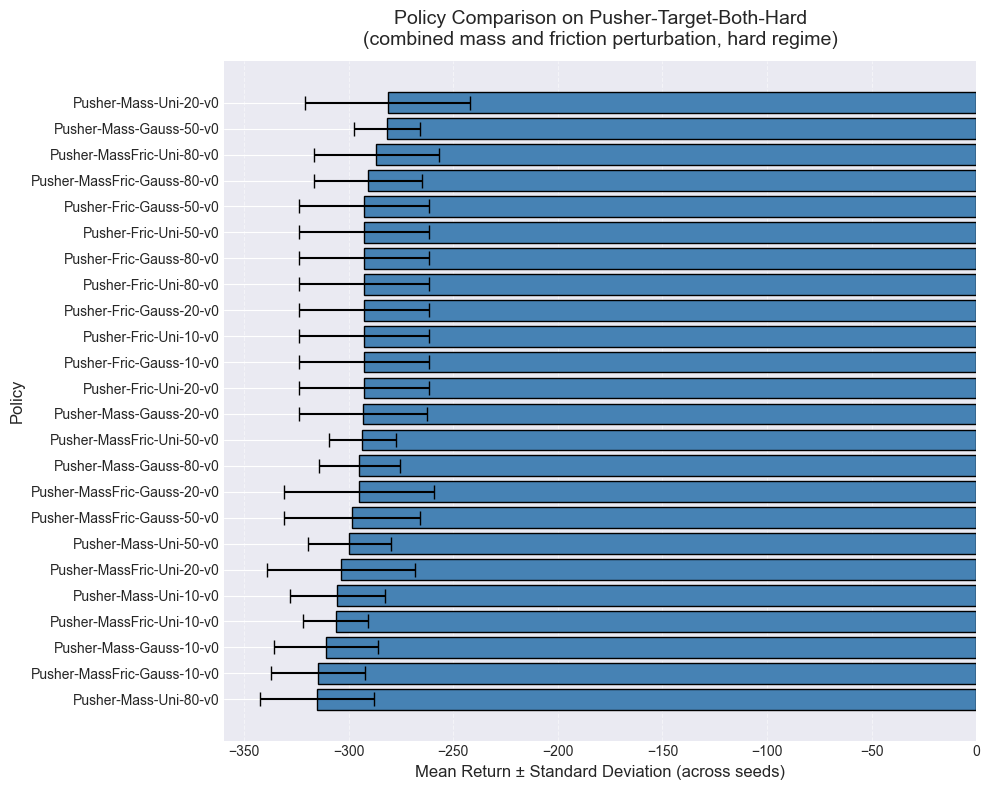

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Data loading ──────────────────────────────────────────────────────────────
df = pd.read_csv('PUSHER_ENV/PPO/results_pusher/evaluation_matrix.csv')

# Identifichiamo le colonne corrette (nel Pusher abbiamo _mean, _std_seed e _std_ep_mean)
mean_cols   = [c for c in df.columns if c.endswith('_mean') and not c.endswith('_std_ep_mean')]
std_cols    = [c for c in df.columns if c.endswith('_std_seed')]
std_ep_cols = [c for c in df.columns if c.endswith('_std_ep_mean')]

clean_labels = [
    c.replace('_mean', '')
     .replace('Pusher-Target-', '')
     .replace('CustomPusher-', '')
    for c in mean_cols
]

# ── Visualisation 1: Mean Reward Heatmap ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

heatmap_data         = df[mean_cols].copy()
heatmap_data.index   = df['policy']
heatmap_data.columns = clean_labels

sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='viridis',
            cbar_kws={'label': 'Mean Return'}, ax=ax)

ax.set_title('Evaluation Matrix: Mean Return across Policies and Tasks (Pusher)', 
             fontsize=15, pad=12)
ax.set_xlabel('Task (Environment)', fontsize=12)
ax.set_ylabel('Policy', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.setp(ax.get_xticklabels(), ha='right')

plt.tight_layout()
plt.savefig('heatmap_results_pusher.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Visualisation 2: Stability Heatmap (Episode Reward Standard Dev) ─────────
# Dato che nel Pusher gli episodi non terminano prima, visualizziamo 
# la stabilità tramite la deviazione standard delle reward
if std_ep_cols:
    fig, ax = plt.subplots(figsize=(14, 10))

    heatmap_std         = df[std_ep_cols].copy()
    heatmap_std.index   = df['policy']
    heatmap_std.columns = clean_labels

    sns.heatmap(heatmap_std, annot=True, fmt=".1f", cmap='magma',
                cbar_kws={'label': 'Reward Std Dev within Episode'}, ax=ax)

    ax.set_title('Stability Matrix: Reward Standard Deviation across Policies and Tasks',
                 fontsize=15, pad=12)
    ax.set_xlabel('Task (Environment)', fontsize=12)
    ax.set_ylabel('Policy', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.get_xticklabels(), ha='right')

    plt.tight_layout()
    plt.savefig('heatmap_stability_pusher.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Visualisation 3: Performance Comparison — Both-Hard ──────────────────────
target_mean = 'Pusher-Target-Both-Hard-v0_mean'
target_std  = 'Pusher-Target-Both-Hard-v0_std_seed'

# Controlla se la colonna esiste per evitare errori
if target_mean in df.columns and target_std in df.columns:
    df_sorted = (df.dropna(subset=[target_mean, target_std])
                   .sort_values(by=target_mean, ascending=True))

    fig, ax = plt.subplots(figsize=(10, 8))

    # Usiamo target_std come barra di errore (rappresenta la variabilità tra i diversi seed)
    ax.barh(df_sorted['policy'], df_sorted[target_mean],
            xerr=df_sorted[target_std],
            color='steelblue', edgecolor='black', capsize=5)

    ax.set_title('Policy Comparison on Pusher-Target-Both-Hard\n'
                 '(combined mass and friction perturbation, hard regime)',
                 fontsize=14, pad=12)
    ax.set_xlabel('Mean Return ± Standard Deviation (across seeds)', fontsize=12)
    ax.set_ylabel('Policy', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('performance_comparison_pusher.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"Colonna {target_mean} non trovata per il bar chart.")
